In [1]:
#se instala para poder separar las imagenes

In [75]:
#imports
import tensorflow as tf
import keras
import os
#librerias para el entrenamiento del modelo
from keras.models import Sequential, load_model
from keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Input

#librerias para mostrar los cambios de la funcion loss
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import splitfolders #para separar el dataset en dif carpetas mientras se entrena todo
import cv2

from keras import layers, models
from keras.applications.resnet50 import preprocess_input

os.environ['CUDA_VISIBLE_DEVICES'] = "0" #para que no salga mensaje de error



In [76]:
input_folder = "dataset"
output_folder = "image-recognition"

In [77]:

split_ratio = (0.8, 0.1, 0.1) #80% imagenes entrenadas, 10% testing, 10% validacion


splitfolders.ratio(
    input_folder,
    output= output_folder,
    seed = 500, #para que cada ves que de dividan las imgs se haga de la misma forma
    ratio = split_ratio,
    group_prefix = None
)


In [78]:
#img_size = (130, 162)
img_size = (224, 224)

batch_size = 16

#Regularización
train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input, #usa la funcion preprocess input de resNet50
    rotation_range=20, #rota las imagenes aleatoreamente
    width_shift_range=0.2, # mueve la imagen de izquierda a la derecha aleatoriamente
    height_shift_range=0.2, #mueve la imagen arriba o abajo aleatoriamente
    shear_range=0.2,
    zoom_range= 0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode= 'nearest'
)

In [79]:
#ambas reescalan las imagenes para que los datos se mantengan
#aumento de datos para datos de testeo
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

#aumento de datos para datos de validacion
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [80]:

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

#lee los datos de las carpetas y las prepara en tandas para entrenar el modelo
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size, 
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

valid_data = valid_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 314 images belonging to 5 classes.


Found 72 images belonging to 5 classes.
Found 80 images belonging to 5 classes.


Este bloque de código es para ver los cambios que se le aplican a una imagen aleatoria

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..113.32].


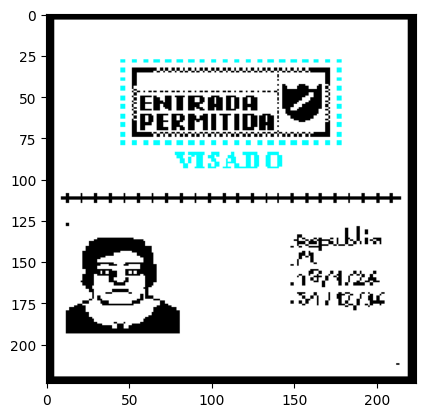

In [81]:
import random
images, labels = next(valid_data)
idx = random.randint(0,images.shape[0]-1)

plt.imshow(images[idx])
plt.show()

Configuracion del modelo a usar: ResNet50

In [82]:
from keras.applications.resnet import ResNet50 #es una cnn que esta entrenada en distintas categorias

base_model = ResNet50(weights='imagenet',include_top=False,input_shape=(img_size[0], img_size[1], 3))
#top son clasificaciones, sin el podemos poner las que se necesiten

#razones :/
base_model.trainable = False

In [83]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), #ambas son fully connected layers
    layers.Dense(128, activation='relu', kernel_regularizer='l2'), #128 neuronas, con funcion de activacion relu
    layers.Dropout(0.25), # desactiva de forma aleatorea 25% de las variables de entrada
    layers.Dense(5, activation='softmax') #5 neuronas, funcion de activacion softmax
])


Compilacion del modelo

In [84]:
model.compile(optimizer='adam', #adaptive moment estimation, es eficiente
    loss='categorical_crossentropy',
    metrics=['accuracy'])

Entrenamiento del modelo

In [85]:
import scipy
#Para el entrenamiento si no disminuye el loss en tres épocas
#callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

#history = model.fit(train_data, epochs=30, validation_data=valid_data, callbacks=[callback])
history = model.fit(train_data, epochs=30, validation_data=valid_data)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 637ms/step - accuracy: 0.3535 - loss: 3.6568 - val_accuracy: 0.5139 - val_loss: 2.7247
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 595ms/step - accuracy: 0.4936 - loss: 2.4680 - val_accuracy: 0.5972 - val_loss: 2.2164
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 592ms/step - accuracy: 0.6019 - loss: 1.9795 - val_accuracy: 0.5972 - val_loss: 1.9369
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 592ms/step - accuracy: 0.6815 - loss: 1.6121 - val_accuracy: 0.5972 - val_loss: 1.6508
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - accuracy: 0.7325 - loss: 1.4126 - val_accuracy: 0.6389 - val_loss: 1.5139
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.7484 - loss: 1.2896 - val_accuracy: 0.5278 - val_loss: 1.5580
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 577ms/step - accuracy: 0.7197 - loss: 1.2071 - val_accuracy: 0.5972 - val_loss: 1.3081
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 590ms/step - accuracy: 0.7611 - loss: 1.1261 - val_accu

Precisión final del modelo

In [86]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f'Precisión de la prueba: {test_accuracy * 100:.2f}%')

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 0.5875 - loss: 1.4331
Precisión de la prueba: 58.75%


Cambio en las funciones de presición y loss

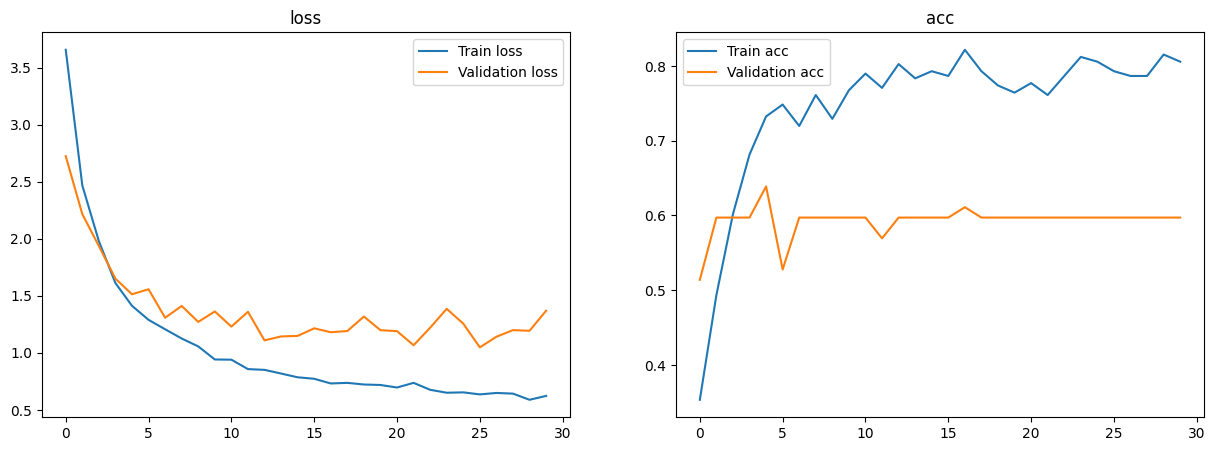

In [87]:
def show_final_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('acc')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

show_final_history(history)

Función para predecir la categoría de la imagen

In [88]:
#aqui se definen las categorías a las que puede pertenecer las imagenes
class_names = {0: 'no-visado', 1: 'pasaporte-valido', 2: 'sin-firma', 3: 'sin-imagen', 4: 'sin-texto'}

In [89]:
def predict_img(image, model):
    test_img=cv2.imread(image)
    test_img=cv2.resize(test_img, (224,224))
    test_img=np.expand_dims(test_img, axis=0)
    result=model.predict(test_img)
    r=np.argmax(result) #valor maximo del arreglo "result"
    print(class_names[r])

In [90]:
predict_img('image-recognition/test/pasaporte-valido/psp_united_6.png', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
pasaporte-valido


In [91]:
predict_img('image-recognition/test/sin-texto/no_txt_united_1.png', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
pasaporte-valido


Despues de esto, se guarda el modelo: (vuelto comentario porque es muy pesado para github)

In [92]:
#model.save('Verificador_Pasaportes.keras')